In [ ]:

# INITIAL
import os, pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
import xgboost as xgb
import cvxpy as cp
import yfinance as yf
import matplotlib.pyplot as plt
import datetime
import time

NIFTY50 = [
    "ADANIPORTS.NS", "ASIANPAINT.NS", "AXISBANK.NS", "BAJAJFINSV.NS",
    "BAJFINANCE.NS", "BHARTIARTL.NS", "CIPLA.NS", "COALINDIA.NS",
    "DIVISLAB.NS", "DRREDDY.NS", "EICHERMOT.NS", "GRASIM.NS",
    "HCLTECH.NS", "HDFCLIFE.NS", "HDFCBANK.NS", "HINDALCO.NS",
    "HINDUNILVR.NS", "ICICIBANK.NS", "INDUSINDBK.NS", "INFY.NS",
    "ITC.NS", "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS",
    "M&M.NS", "MARUTI.NS", "NESTLEIND.NS", "NTPC.NS",
    "ONGC.NS", "POWERGRID.NS", "RELIANCE.NS", "SBIN.NS",
    "SHREECEM.NS", "SUNPHARMA.NS", "TATACONSUM.NS", "TATAMOTORS.NS",
    "TATASTEEL.NS", "TECHM.NS", "TITAN.NS", "ULTRACEMCO.NS", "WIPRO.NS"
]

# Cached, throttled helper for yfinance info()
def fetch_info(ticker, pause=0.5):
    cache_dir = 'yf_cache'
    os.makedirs(cache_dir, exist_ok=True)
    path = f"{cache_dir}/{ticker}.pkl"
    if os.path.exists(path):
        return pickle.load(open(path, 'rb'))
    info = yf.Ticker(ticker).info
    pickle.dump(info, open(path, 'wb'))
    time.sleep(pause)
    return info



In [ ]:
#############################
# 0. Use Your Own Fama-French Factors DataFrame
#############################
def get_ff_factors():
    print("Using custom Fama-French factor DataFrame...")
    price_data = yf.download(NIFTY50, period='1y', interval='1mo', progress=False)['Close']
    monthly_returns = price_data.pct_change().dropna()
    avg_monthly_return = monthly_returns.mean()
    data_list = []
    for ticker in NIFTY50:
        info = fetch_info(ticker)
        market_cap = info.get('marketCap', np.nan)
        book_value = info.get('bookValue', np.nan)
        price = price_data[ticker].iloc[-1] if ticker in price_data.columns else np.nan
        btom = book_value/price if pd.notnull(book_value) and pd.notnull(price) else np.nan
        op_margin = info.get('operatingMargins', np.nan)
        bs = yf.Ticker(ticker).balance_sheet
        asset_growth = np.nan
        if not bs.empty and 'Total Assets' in bs.index and bs.shape[1]>=2:
            dates = bs.columns.sort_values(ascending=False)
            latest = bs.loc['Total Assets', dates[0]]
            prev   = bs.loc['Total Assets', dates[1]]
            asset_growth = (latest-prev)/prev if prev!=0 else np.nan
        ret = avg_monthly_return.get(ticker, np.nan)
        data_list.append({
            'Ticker': ticker,
            'MarketCap': market_cap,
            'BookValue': book_value,
            'BookToMarket': btom,
            'OpMargin': op_margin,
            'AssetGrowth': asset_growth,
            'Return': ret
        })
    df = pd.DataFrame(data_list).dropna(subset=['MarketCap','BookToMarket','Return','OpMargin','AssetGrowth'])
    df['Size']          = np.where(df['MarketCap']<df['MarketCap'].median(),'Small','Big')
    df['Value']         = np.where(df['BookToMarket']>df['BookToMarket'].median(),'High','Low')
    df['Profitability'] = np.where(df['OpMargin']>df['OpMargin'].median(),'Robust','Weak')
    df['Investment']    = np.where(df['AssetGrowth']<df['AssetGrowth'].median(),'Conservative','Aggressive')
    SMB = df[df['Size']=='Small']['Return'].mean() - df[df['Size']=='Big']['Return'].mean()
    HML = df[df['Value']=='High']['Return'].mean() - df[df['Value']=='Low']['Return'].mean()
    RMW = df[df['Profitability']=='Robust']['Return'].mean() - df[df['Profitability']=='Weak']['Return'].mean()
    CMA = df[df['Investment']=='Conservative']['Return'].mean() - df[df['Investment']=='Aggressive']['Return'].mean()
    Mkt_RF = df['Return'].mean() - 0.0667
    factor_names  = ['Mkt-RF','SMB','HML','RMW','CMA','RF']
    factor_values = [Mkt_RF, SMB, HML, RMW, CMA, 0.0667]
    factors_df = pd.DataFrame({'Factor':factor_names,'Value':factor_values})
    print("\nCalculated Fama–French 5-Factor Model Components (with RF):")
    return factors_df



In [ ]:
#############################
# 1. Data Loading using yfinance
#############################
def batch_download(tickers, start, end, chunk_size=10, pause=2):
    parts = []
    for i in range(0, len(tickers), chunk_size):
        batch = tickers[i:i+chunk_size]
        df = yf.download(batch, start=start, end=end,
                         progress=False, auto_adjust=False)['Close']
        parts.append(df)
        time.sleep(pause)
    return pd.concat(parts, axis=1)

# Pre-download once
start_date = (pd.Timestamp.today() - pd.DateOffset(years=5)).strftime("%Y-%m-%d")
end_date   = pd.Timestamp.today().strftime("%Y-%m-%d")
all_prices = batch_download(NIFTY50, start_date, end_date)

# Benchmark as DataFrame, renamed correctly
bench_all = yf.download("^NSEI", start=start_date, end=end_date,
                        progress=False, auto_adjust=False)[['Close']]
bench_all.rename(columns={'Close': 'Index'}, inplace=True)

def get_top_nifty_stocks(n=15):
    caps = pd.Series({t: fetch_info(t).get('marketCap', 0) for t in NIFTY50})
    top = caps.nlargest(n).index.tolist()
    data = all_prices[top].dropna(how='all')
    return data, caps.loc[top]

def load_nifty_data(n=15):
    stocks, caps = get_top_nifty_stocks(n)
    # Align dates between stocks and benchmark to avoid KeyError
    common = stocks.index.intersection(bench_all.index)
    stocks   = stocks.loc[common]
    benchmark= bench_all.loc[common]
    return stocks, benchmark, caps





In [ ]:
#############################
# 2. Additional Feature Functions: Fundamental, Technical & Sentiment
#############################
def get_fundamental_features(ticker):
    info = fetch_info(ticker)
    return {
        'trailingPE': info.get('trailingPE', np.nan),
        'priceToBook': info.get('priceToBook', np.nan)
    }

def compute_RSI(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_g = gain.rolling(window).mean()
    avg_l = loss.rolling(window).mean()
    rs = avg_g/avg_l
    return (100 - 100/(1+rs)).fillna(50)

def generate_asset_features_for_stock(ticker, asset_prices, f_data):
    df = pd.DataFrame(index=asset_prices.index)
    df['price']        = asset_prices
    df['SMA20']        = asset_prices.rolling(20, min_periods=1).mean()
    df['SMA50']        = asset_prices.rolling(50, min_periods=1).mean()
    df['mom21']        = asset_prices.pct_change(21).fillna(0)
    df['daily_return'] = asset_prices.pct_change().fillna(0)
    df['RSI']          = compute_RSI(asset_prices)
    df['trailingPE']   = f_data['trailingPE']
    df['priceToBook']  = f_data['priceToBook']
    return df



In [ ]:
#############################
# 3. Preprocessing and Feature Engineering
#############################
def compute_returns(prices):
    return prices.pct_change().dropna()

def generate_features(df, degree=1):
    clean = df.fillna(0)
    poly  = PolynomialFeatures(degree=degree, include_bias=False)
    arr   = poly.fit_transform(clean)
    return pd.DataFrame(arr, index=clean.index, columns=poly.get_feature_names_out())

#############################
# 4. XGBoost Model Training
#############################
def train_xgb_model(X_train, y_train):
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=0.5,
        reg_lambda=0.5,
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

#############################
# 5. Black-Litterman Functions
#############################
def compute_equilibrium_returns(cov_matrix, market_weights, risk_aversion):
    return risk_aversion * cov_matrix.dot(market_weights)

def bl_update(Pi, tau, cov_matrix, P, Q, Omega):
    inv_tau = np.linalg.inv(tau * cov_matrix)
    inv_O   = np.linalg.inv(Omega)
    M       = np.linalg.inv(inv_tau + P.T.dot(inv_O).dot(P))
    mu      = M.dot(inv_tau.dot(Pi) + P.T.dot(inv_O).dot(Q))
    return mu, M

#############################
# 6. Portfolio Optimization (Local Risk-Aversion Optimized)
#############################
def optimize_portfolio(expected_returns, cov_matrix, local_risk_aversion):
    n = len(expected_returns)
    w = cp.Variable(n)
    obj = cp.Minimize(
        local_risk_aversion * cp.quad_form(w, cov_matrix)
        - expected_returns.T @ w
    )
    cons = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 1      # cap any single position at 10%
    ]
    prob = cp.Problem(obj, cons)
    prob.solve()
    return w.value



In [ ]:
#############################
# 7. Rolling Window Backtest with Fundamental, Technical & Sentiment Data
#############################
def rolling_window_backtest(
    stocks, returns, market_weights,
    window_train=150, window_test=30,
    risk_aversion=2.5, tau=0.10,
    local_risk_aversion=1.25, use_views=True
):
    dates       = returns.index
    n_assets    = returns.shape[1]
    port_rets   = []
    weights_hist= []
    P           = np.eye(n_assets)

    # initial fundamentals
    fund_dict = {t: get_fundamental_features(t) for t in returns.columns}

    for start in range(0, len(dates)-window_train-window_test, window_test):
        train_dates = dates[start:start+window_train]
        test_dates  = dates[start+window_train:start+window_train+window_test]
        R_train     = returns.loc[train_dates]
        preds       = np.zeros((window_test, n_assets))
        res_vars    = np.full(n_assets, 0.05)

        # 1) generate & predict with simplified features
        for i,t in enumerate(returns.columns):
            prices_tr = stocks[t].loc[train_dates]
            prices_ts = stocks[t].loc[test_dates]
            fdata     = fund_dict[t]
            X_tr_asset= generate_asset_features_for_stock(t, prices_tr, fdata)
            X_ts_asset= generate_asset_features_for_stock(t, prices_ts, fdata)
            X_tr = generate_features(X_tr_asset, degree=1)
            X_ts = generate_features(X_ts_asset, degree=1)
            if use_views:
                m    = train_xgb_model(X_tr, R_train[t])
                p    = m.predict(X_ts)
                preds[:,i] = p
                resid = R_train[t] - m.predict(X_tr)
                res_vars[i]= np.var(resid)

        # 2) cap & build Omega
        res_vars = np.maximum(res_vars, 1e-4)
        Omega    = np.diag(res_vars)

        # 3) shrink covariance
        Σ = R_train.cov().values
        α = 0.1
        Σ = (1-α)*Σ + α*np.diag(np.diag(Σ))

        # 4) compute π and Q with view‐shrinkage
        π = compute_equilibrium_returns(Σ, market_weights, risk_aversion)
        if use_views:
            Q = preds.mean(axis=0)
            Q = 0.8*Q + 0.2*π
        else:
            Q = π

        # 5) posterior & optimize
        μ_post, _ = bl_update(π, tau, Σ, P, Q, Omega)
        w_opt     = optimize_portfolio(μ_post, Σ, local_risk_aversion)
        # —————————— Guard against solver failure ——————————
        if w_opt is None:
          # fallback to equal weights if optimization fails
          w_opt = np.ones(n_assets) / n_assets

        weights_hist.append(w_opt)

        # pull out the test‐window slice
        sub = returns.loc[test_dates]

        # ensure we have a DataFrame (len 1 → Series)
        if isinstance(sub, pd.Series):
            sub = sub.to_frame().T

        # compute portfolio return(s)
        arr = sub.values.dot(w_opt)  # shape (n_rows,)
        ret = pd.Series(arr, index=sub.index)

        port_rets.append(ret)

    portfolio_returns = pd.concat(port_rets)
    weights_history  = pd.DataFrame(weights_hist,
                        index=portfolio_returns.index[::window_test],
                        columns=returns.columns)
    # At the end of rolling_window_backtest, after building Omega:
    last_window_train = dates[-(window_train + window_test):-window_test]
    returns_last = returns.loc[last_window_train]
    cov_matrix_last = returns_last.cov().values
    Pi_last = compute_equilibrium_returns(cov_matrix_last, market_weights, risk_aversion)

    # recompute predictions on final window
    preds_last = np.zeros((window_test, n_assets))
    for i, t in enumerate(returns.columns):
        prices_tr   = stocks[t].loc[last_window_train]
        prices_ts   = stocks[t].iloc[-window_test:]
        fdata       = get_fundamental_features(t)
        X_tr_asset  = generate_asset_features_for_stock(t, prices_tr, fdata)
        X_ts_asset  = generate_asset_features_for_stock(t, prices_ts, fdata)
        X_tr        = generate_features(X_tr_asset, degree=1)
        X_ts        = generate_features(X_ts_asset, degree=1)
        if use_views:
            m = train_xgb_model(X_tr, returns_last[t])
            preds_last[:, i] = m.predict(X_ts)
    Q_last = preds_last.mean(axis=0)

    last_params = (Pi_last, Q_last, cov_matrix_last, P, Omega)
    return portfolio_returns, weights_history, last_params




Running model: All 50 With Views

Running model: Top 15 With Views

Running model: Top 10 With Views


[*********************100%***********************]  1 of 1 completed


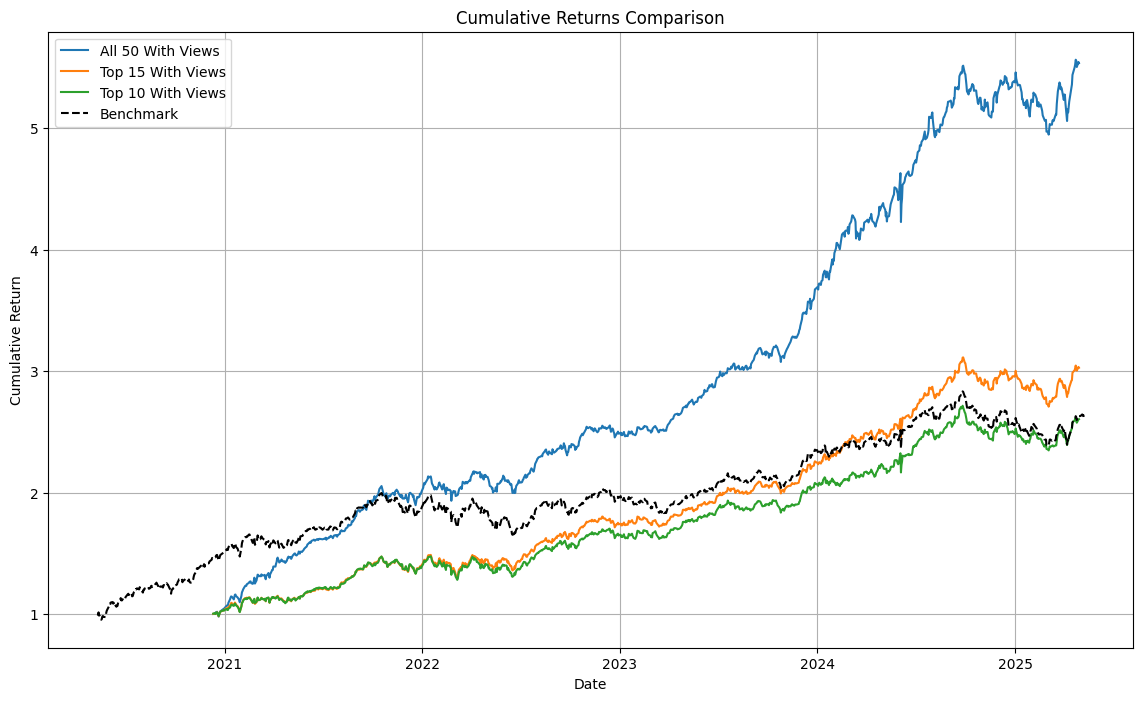

Overall Performance Metrics:
                                           All 50 With Views  \
Annual Return                                        0.41015   
Annual Volatility                                   0.144877   
Sharpe Ratio                                        2.363724   
Max Drawdown                                       -0.102846   
Return vs Benchmark  Ticker
^NSEI    0.200862
dtype: float64   

                                           Top 15 With Views  \
Annual Return                                       0.268175   
Annual Volatility                                   0.137963   
Sharpe Ratio                                          1.4531   
Max Drawdown                                       -0.130333   
Return vs Benchmark  Ticker
^NSEI    0.058887
dtype: float64   

                                           Top 10 With Views  
Annual Return                                       0.233745  
Annual Volatility                                   0.143096  
Sharpe Ratio

In [ ]:
#############################
# 8. Performance Metrics Calculation
#############################
def calculate_overall_metrics(port_returns, benchmark_returns, risk_free_rate=0.0677):
    annual_ret = port_returns.mean() * 252
    annual_vol = port_returns.std()  * np.sqrt(252)
    sharpe     = (annual_ret - risk_free_rate) / annual_vol if annual_vol!=0 else np.nan
    cum_ret    = (1 + port_returns).cumprod()
    max_dd     = ((cum_ret - cum_ret.cummax())/cum_ret.cummax()).min()
    bench_ret  = benchmark_returns['Index'].mean()*252
    return {
        "Annual Return": annual_ret,
        "Annual Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Return vs Benchmark": annual_ret - bench_ret
    }

#############################
# 9. Main Execution and Plotting
#############################
if __name__ == "__main__":
    model_configs = [
        {"n":50, "use_views":True,  "label":"All 50 With Views"},
        {"n":15, "use_views":True,  "label":"Top 15 With Views"},
        {"n":10, "use_views":True,  "label":"Top 10 With Views"}
    ]

    results = {}
    for cfg in model_configs:
        print(f"\nRunning model: {cfg['label']}")
        stocks, bench, caps = load_nifty_data(n=cfg["n"])
        R_stocks   = compute_returns(stocks)
        R_bench    = compute_returns(bench)
        w_market   = (caps/caps.sum()).values
        λ_market   = R_bench.mean().values[0]/R_bench.var().values[0]

        port_ret, w_hist, last_params = rolling_window_backtest(
            stocks, R_stocks,
            market_weights=w_market,
            use_views=cfg["use_views"],
            window_train=150,
            window_test=30,
            risk_aversion=λ_market,
            tau=0.10,
            local_risk_aversion=λ_market
        )
        cumrets = (1+port_ret).cumprod()
        metrics = calculate_overall_metrics(port_ret, R_bench)
        results[cfg["label"]] = {
            "cum_returns": cumrets,
            "overall_metrics":metrics,
            "last_params": last_params,
            "lambda_market":   λ_market
        }

    plt.figure(figsize=(14,8))
    for label,res in results.items():
        plt.plot(res["cum_returns"], label=label)
    # plot benchmark
    bench5y = (1+compute_returns(
        yf.download("^NSEI",period="5y",interval="1d")['Close']
    )).cumprod()
    plt.plot(bench5y, '--', color='black', label="Benchmark")
    plt.title("Cumulative Returns Comparison")
    plt.xlabel("Date"); plt.ylabel("Cumulative Return")
    plt.legend(); plt.grid(True); plt.show()

    df_metrics = pd.DataFrame({k:v["overall_metrics"] for k,v in results.items()})
    print("Overall Performance Metrics:"); print(df_metrics)



[*********************100%***********************]  1 of 1 completed


                        0.5           0.6           0.7           0.8  \
Ticker                                                                  
RELIANCE.NS   -5.292526e-23  5.313794e-23 -3.650174e-23 -1.046597e-22   
HDFCBANK.NS    1.721627e-01  1.675263e-01  1.628313e-01  1.580692e-01   
BHARTIARTL.NS  3.825877e-02  4.181573e-02  4.532897e-02  4.879224e-02   
ICICIBANK.NS   1.386310e-01  1.462932e-01  1.539027e-01  1.614522e-01   
SBIN.NS       -4.029779e-23 -3.395051e-23 -2.756532e-23 -7.500510e-23   
INFY.NS        4.876881e-02  4.596551e-02  4.325793e-02  4.065973e-02   
HINDUNILVR.NS  8.686975e-02  8.294893e-02  7.795963e-02  7.174911e-02   
BAJFINANCE.NS  5.878831e-02  7.307979e-02  8.738169e-02  1.016955e-01   
ITC.NS         6.146144e-02  5.509297e-02  4.828743e-02  4.098232e-02   
LT.NS          3.057047e-23  8.733090e-24 -9.065796e-23 -1.186040e-22   
HCLTECH.NS     3.697946e-02  3.562900e-02  3.430306e-02  3.300514e-02   
SUNPHARMA.NS   5.540538e-02  5.422817e-02  5.288955

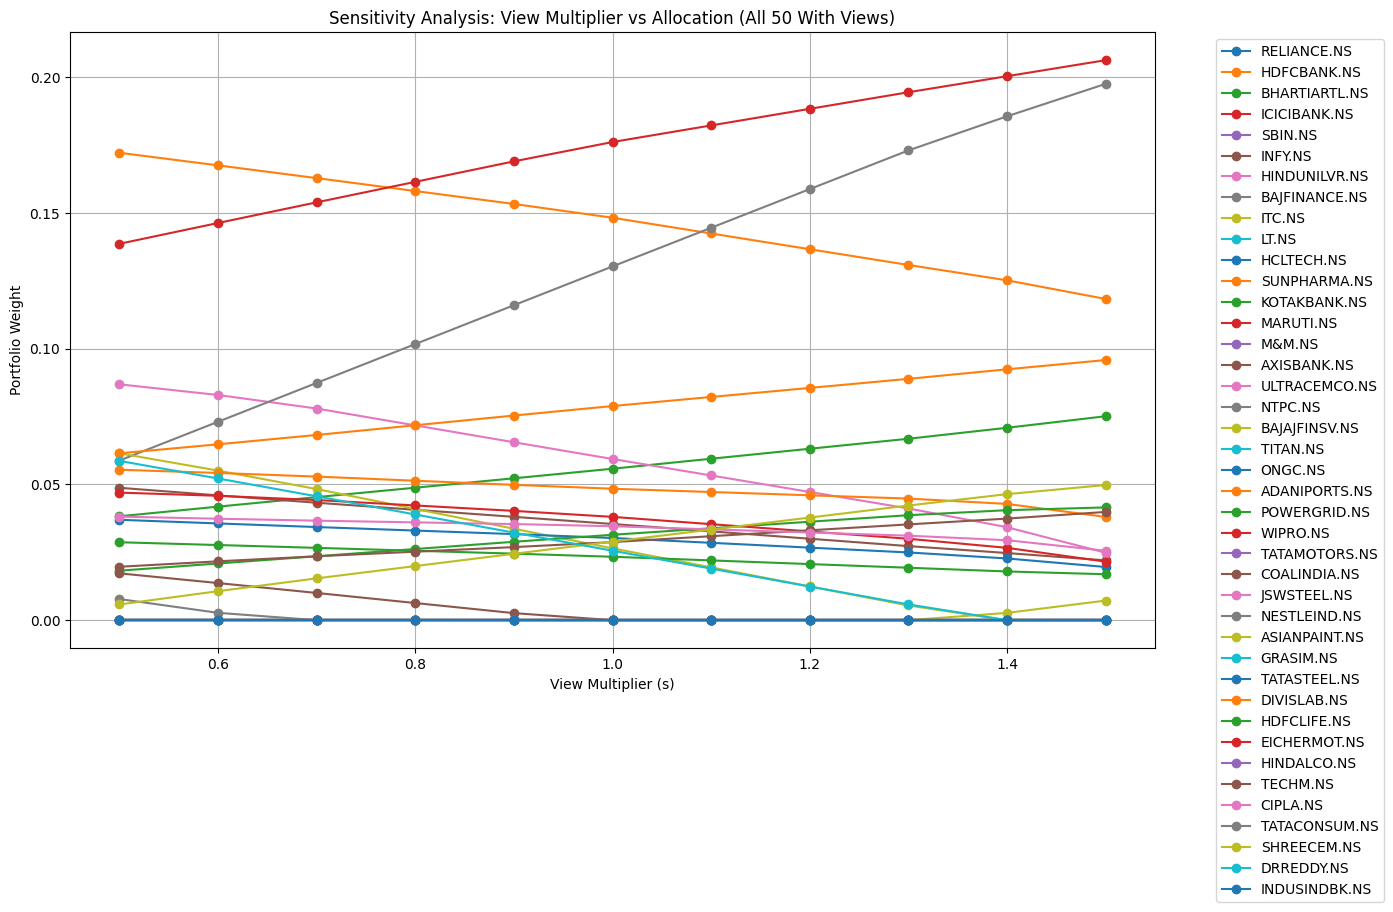

In [ ]:
# — Snippet 12 (Revised for Model 2) —
# Sensitivity Analysis: Impact of View Multiplier on All-50 Allocation

# 1) Unpack the stored BL parameters from your results dict
Pi, Q_last, cov_matrix_sample, P, Omega = results["All 50 With Views"]["last_params"]

# 2) Use the same tickers order you backtested
tickers = load_nifty_data(50)[0].columns

# 3) Set your exact τ and λ you used in the main backtest
tau     = 0.10                    # same τ used in your main run
λ_market = results["All 50 With Views"]["overall_metrics"]  # not used here, see below

# If you need λ, recompute it exactly as you did:
R_bench = compute_returns(yf.download("^NSEI",period="5y",interval="1d")["Close"])
λ      = R_bench.mean() / R_bench.var()

# 4) Build the sensitivity matrix (rows = multipliers, cols = tickers)
multipliers = np.linspace(0.5, 1.5, 11)
sens_list   = []
for s in multipliers:
    mu_s, _ = bl_update(Pi, tau, cov_matrix_sample, P, s * Q_last, Omega)
    lambda50 = results["All 50 With Views"]["lambda_market"]
    w_s     = optimize_portfolio(mu_s, cov_matrix_sample, lambda50)
    if w_s is None:
        w_s = np.ones(len(tickers)) / len(tickers)
    sens_list.append(w_s)

sens_df = pd.DataFrame(sens_list, index=multipliers, columns=tickers)
print(sens_df.T)

# 5) And finally plot
plt.figure(figsize=(14,8))
for t in sens_df.columns:
    plt.plot(sens_df.index, sens_df[t], marker='o', label=t)
plt.title("Sensitivity Analysis: View Multiplier vs Allocation (All 50 With Views)")
plt.xlabel("View Multiplier (s)")
plt.ylabel("Portfolio Weight")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.show()


Tickers sorted by weight at s=1.5:
ICICIBANK.NS
BAJFINANCE.NS
HDFCBANK.NS
DIVISLAB.NS
BHARTIARTL.NS
SHREECEM.NS
KOTAKBANK.NS
TECHM.NS
SUNPHARMA.NS
CIPLA.NS
HINDUNILVR.NS
INFY.NS
MARUTI.NS
HCLTECH.NS
HDFCLIFE.NS
BAJAJFINSV.NS
ITC.NS
AXISBANK.NS
NESTLEIND.NS
DRREDDY.NS


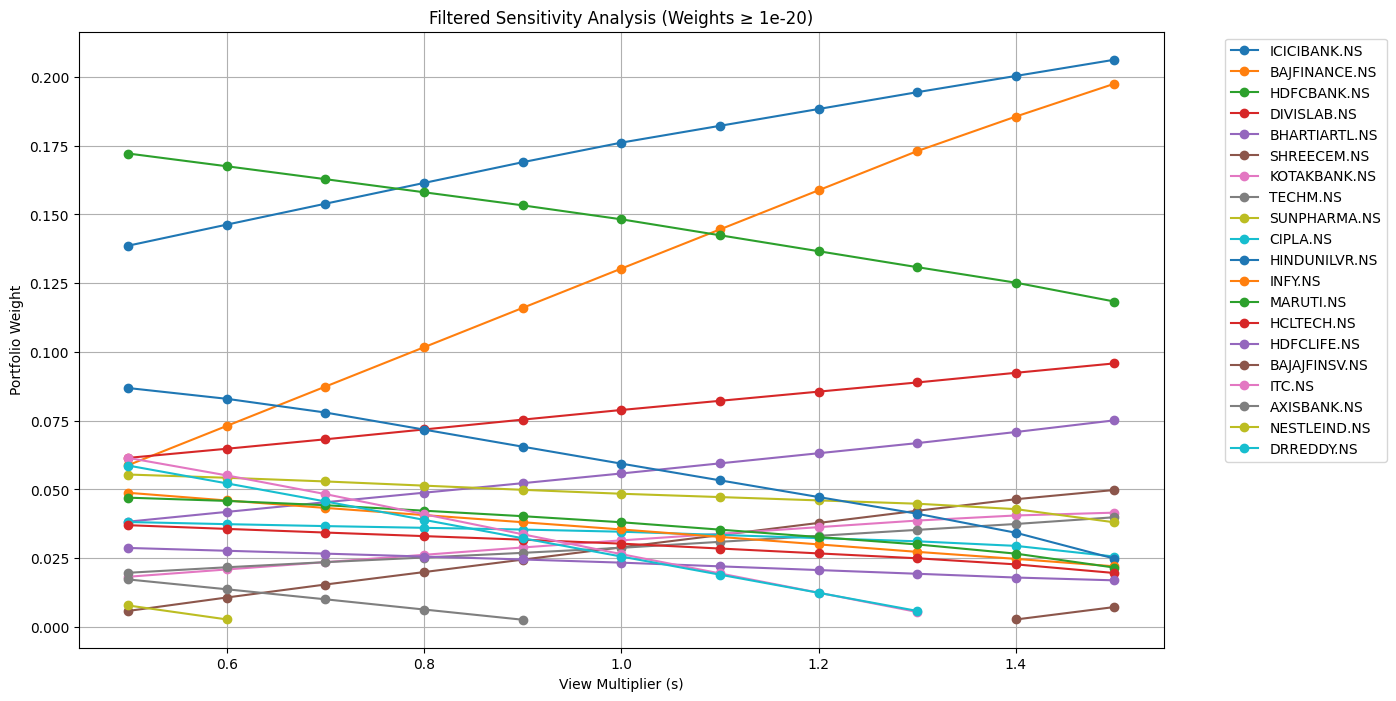

In [ ]:
import matplotlib.pyplot as plt

# 1) Compute your cleaned sensitivity matrix (if not already in scope)
threshold = 1e-20
sens_df_filtered = sens_df.where(sens_df.abs() >= threshold)
sens_df_clean    = sens_df_filtered.dropna(axis=1, how='all')

# 2) Get tickers sorted by their weight at s = 1.5 (descending)
sorted_tickers = sens_df_clean.loc[1.5].sort_values(ascending=False).index

# (Optional) Print the sorted names:
print("Tickers sorted by weight at s=1.5:")
for t in sorted_tickers:
    print(t)

# 3) Plot in that order, so the legend on the right is sorted
plt.figure(figsize=(14, 8))
for ticker in sorted_tickers:
    plt.plot(sens_df_clean.index, sens_df_clean[ticker], marker='o', label=ticker)

plt.title("Filtered Sensitivity Analysis (Weights ≥ 1e-20)")
plt.xlabel("View Multiplier (s)")
plt.ylabel("Portfolio Weight")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


## 10. RAG Chatbot for This Notebook

This section adds a grounded RAG chatbot that can answer questions about:
- the Black-Litterman workflow in this notebook,
- the latest backtest metrics stored in `results`,
- the sensitivity analysis in `sens_df` / `sens_df_clean`, and
- any extra PDFs, CSVs, TXT, MD, or IPYNB files you place inside a local `rag_docs/` folder.

How it works:
1. It converts notebook summaries and optional external documents into chunks.
2. It embeds them locally with a Sentence-Transformers model.
3. It stores them in a FAISS vector index.
4. It retrieves the most relevant chunks for each question.
5. If `OPENAI_API_KEY` is available, it generates a grounded answer; otherwise it returns a retrieval-based answer with the best matching excerpts.


In [ ]:
# Install only once in a fresh environment
%pip install -qU langchain langchain-community langchain-openai langchain-huggingface langchain-text-splitters faiss-cpu sentence-transformers pypdf ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

In [ ]:
from google.colab import userdata
import os

# Read from Colab Secrets
groq_key = userdata.get("GROQ_TOKEN")

# Optional: expose it as an env var for SDKs/libraries
os.environ["GROQ_TOKEN"] = groq_key

print("Loaded:", "yes" if groq_key else "no")

Loaded: yes


In [ ]:
import os
import json
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
from pypdf import PdfReader
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

try:
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
except Exception:
    ChatOpenAI = None
    ChatPromptTemplate = None

RAG_DOCS_DIR = Path("rag_docs")
RAG_INDEX_DIR = Path("rag_index")
RAG_INDEX_DIR.mkdir(exist_ok=True)


def _safe_markdown_table(df, max_rows=12):
    if df is None or len(df) == 0:
        return "No rows available."
    preview = df.head(max_rows).copy()
    return preview.to_markdown(index=True)


def _series_to_text(s, max_items=20):
    if s is None or len(s) == 0:
        return "No values available."
    s = s.head(max_items)
    return "\n".join([f"- {idx}: {val}" for idx, val in s.items()])


def build_notebook_documents():
    docs = []

    overview = """
    Notebook overview:
    - Builds a Black-Litterman portfolio workflow for NIFTY assets.
    - Downloads market data with yfinance.
    - Generates technical, fundamental, and simplified feature-engineering inputs.
    - Trains XGBoost models to form views.
    - Uses a Black-Litterman posterior update and cvxpy optimization.
    - Runs rolling-window backtests.
    - Computes cumulative returns, annualized metrics, and sensitivity analysis.
    """
    docs.append(Document(page_content=textwrap.dedent(overview).strip(), metadata={"source": "notebook_overview"}))

    methodology = """
    Core methodology implemented in the notebook:
    1. Download stock prices and benchmark data.
    2. Compute returns.
    3. Generate per-stock features including SMA20, SMA50, 21-day momentum, daily return, RSI, trailing PE, and price-to-book.
    4. Train XGBoost regression models to predict return views when use_views=True.
    5. Build the Black-Litterman equilibrium return vector Pi from covariance, market weights, and risk aversion.
    6. Combine Pi with model views Q and uncertainty matrix Omega.
    7. Optimize long-only weights with sum(weights)=1 and 0<=weights<=1.
    8. Evaluate cumulative returns and portfolio metrics.
    """
    docs.append(Document(page_content=textwrap.dedent(methodology).strip(), metadata={"source": "methodology"}))

    if "results" in globals() and isinstance(results, dict) and results:
        for model_name, payload in results.items():
            metrics = payload.get("overall_metrics", {})
            cum_returns = payload.get("cum_returns", None)
            lines = [f"Model: {model_name}"]
            if metrics:
                lines.append("Performance metrics:")
                for k, v in metrics.items():
                    lines.append(f"- {k}: {v}")
            if isinstance(cum_returns, pd.Series) and not cum_returns.empty:
                lines.append(f"Latest cumulative return value: {cum_returns.iloc[-1]}")
                lines.append(f"Latest cumulative return date: {cum_returns.index[-1]}")
            docs.append(Document(page_content="\n".join(lines), metadata={"source": "results", "model": model_name}))

    if "sens_df_clean" in globals() and isinstance(sens_df_clean, pd.DataFrame) and not sens_df_clean.empty:
        top_at_high = sens_df_clean.loc[sens_df_clean.index.max()].sort_values(ascending=False).head(10)
        sens_text = "Sensitivity analysis summary (filtered):\n"
        sens_text += "Top allocations at the highest multiplier in sens_df_clean:\n"
        sens_text += _series_to_text(top_at_high)
        docs.append(Document(page_content=sens_text, metadata={"source": "sensitivity_analysis_filtered"}))
    elif "sens_df" in globals() and isinstance(sens_df, pd.DataFrame) and not sens_df.empty:
        top_at_high = sens_df.loc[sens_df.index.max()].sort_values(ascending=False).head(10)
        sens_text = "Sensitivity analysis summary:\n"
        sens_text += "Top allocations at the highest multiplier in sens_df:\n"
        sens_text += _series_to_text(top_at_high)
        docs.append(Document(page_content=sens_text, metadata={"source": "sensitivity_analysis"}))

    if "NIFTY50" in globals():
        ticker_text = "Universe used in the notebook includes these NIFTY tickers:\n" + "\n".join([f"- {t}" for t in NIFTY50])
        docs.append(Document(page_content=ticker_text, metadata={"source": "ticker_universe"}))

    return docs


def read_external_file(path: Path):
    suffix = path.suffix.lower()
    try:
        if suffix in {".txt", ".md", ".py", ".json", ".html", ".htm"}:
            text = path.read_text(encoding="utf-8", errors="ignore")
            return [Document(page_content=text, metadata={"source": str(path)})]
        if suffix == ".csv":
            df = pd.read_csv(path)
            text = f"CSV file: {path.name}\n\n" + _safe_markdown_table(df, max_rows=20)
            return [Document(page_content=text, metadata={"source": str(path)})]
        if suffix in {".xlsx", ".xls"}:
            xls = pd.ExcelFile(path)
            docs = []
            for sheet in xls.sheet_names:
                df = pd.read_excel(path, sheet_name=sheet)
                text = f"Excel file: {path.name} | Sheet: {sheet}\n\n" + _safe_markdown_table(df, max_rows=20)
                docs.append(Document(page_content=text, metadata={"source": str(path), "sheet": sheet}))
            return docs
        if suffix == ".pdf":
            reader = PdfReader(str(path))
            pages = []
            for i, page in enumerate(reader.pages):
                txt = page.extract_text() or ""
                if txt.strip():
                    pages.append(Document(page_content=txt, metadata={"source": str(path), "page": i + 1}))
            return pages
        if suffix == ".ipynb":
            nb_data = json.loads(path.read_text(encoding="utf-8", errors="ignore"))
            docs = []
            for i, cell in enumerate(nb_data.get("cells", [])):
                src = "".join(cell.get("source", []))
                if src.strip():
                    docs.append(Document(page_content=src, metadata={"source": str(path), "cell": i, "type": cell.get("cell_type", "unknown")}))
            return docs
    except Exception as e:
        return [Document(page_content=f"Failed to parse {path.name}: {e}", metadata={"source": str(path), "error": True})]
    return []


def load_external_documents(folder=RAG_DOCS_DIR):
    docs = []
    folder = Path(folder)
    if not folder.exists():
        folder.mkdir(parents=True, exist_ok=True)
        return docs
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            docs.extend(read_external_file(path))
    return docs


def build_vectorstore(force_rebuild=False, extra_docs_dir=RAG_DOCS_DIR):
    index_file = RAG_INDEX_DIR / "index.faiss"
    pkl_file = RAG_INDEX_DIR / "index.pkl"
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

    if index_file.exists() and pkl_file.exists() and not force_rebuild:
        return FAISS.load_local(str(RAG_INDEX_DIR), embeddings, allow_dangerous_deserialization=True)

    docs = build_notebook_documents() + load_external_documents(extra_docs_dir)
    splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
    chunks = splitter.split_documents(docs)
    vectorstore = FAISS.from_documents(chunks, embeddings)
    vectorstore.save_local(str(RAG_INDEX_DIR))
    return vectorstore


vectorstore = build_vectorstore(force_rebuild=True)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
print("RAG index ready.")
print(f"Indexed chunks: {vectorstore.index.ntotal}")
print(f"Optional external docs folder: {RAG_DOCS_DIR.resolve()}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

RAG index ready.
Indexed chunks: 2
Optional external docs folder: /content/rag_docs


In [ ]:
if ChatPromptTemplate is not None:
    RAG_PROMPT = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a grounded portfolio-analysis assistant for this Black-Litterman notebook.
            Answer only from the retrieved context.
            If the answer is not supported by the retrieved context, say that clearly.
            Prefer concise, analytical answers.
            End with a short Sources section listing the retrieved sources you used.
            """
        ),
        (
            "human",
            """
            Question: {question}

            Conversation history:
            {history}

            Retrieved context:
            {context}
            """
        )
    ])
else:
    RAG_PROMPT = None

chat_history = []


def _format_docs(docs):
    blocks = []
    for i, doc in enumerate(docs, start=1):
        meta = ", ".join([f"{k}={v}" for k, v in doc.metadata.items()])
        blocks.append(f"[Chunk {i} | {meta}]\n{doc.page_content}")
    return "\n\n".join(blocks)


def _history_to_text(history, max_turns=4):
    recent = history[-max_turns:]
    if not recent:
        return "No prior conversation."
    lines = []
    for turn in recent:
        lines.append(f"User: {turn['user']}")
        lines.append(f"Assistant: {turn['assistant']}")
    return "\n".join(lines)


def _fallback_answer(question, docs):
    header = "No GROQ_API_KEY detected, so this is a retrieval-only grounded response.\n\n"
    bullets = []
    for i, doc in enumerate(docs[:3], start=1):
        snippet = doc.page_content[:700].strip().replace("\n\n", "\n")
        bullets.append(f"Source {i} ({doc.metadata}):\n{snippet}")
    return header + "\n\n".join(bullets)


def ask_rag(question, k=5):
    docs = retriever.invoke(question)
    context = _format_docs(docs)
    history = _history_to_text(chat_history)

    if ChatOpenAI is not None and RAG_PROMPT is not None and os.getenv("GROQ_TOKEN"):
        llm = ChatOpenAI(
            model="llama-3.3-70b-versatile",
            api_key=os.environ["GROQ_TOKEN"],
            base_url="https://api.groq.com/openai/v1",
            temperature=0
        )
        answer = llm.invoke(
            RAG_PROMPT.format_messages(
                question=question,
                context=context,
                history=history
            )
        ).content
    else:
        answer = _fallback_answer(question, docs)

    chat_history.append({"user": question, "assistant": answer})
    return answer, docs



# Example:
# answer, docs = ask_rag("Which model had the best Sharpe ratio and why?")


In [ ]:
# Simple notebook chatbot UI
question_box = widgets.Textarea(
    value="",
    placeholder="Ask about the backtest, model assumptions, metrics, sensitivity analysis, or anything inside rag_docs/...",
    description="Question:",
    layout=widgets.Layout(width="100%", height="100px")
)

ask_button = widgets.Button(description="Ask RAG Bot", button_style="primary")
clear_button = widgets.Button(description="Clear Chat", button_style="warning")
output_box = widgets.Output()


def _render_sources(docs):
    lines = ["\nRetrieved chunks:"]
    for i, doc in enumerate(docs, start=1):
        lines.append(f"{i}. {doc.metadata}")
    return "\n".join(lines)


def on_ask_clicked(_):
    question = question_box.value.strip()
    with output_box:
        if not question:
            clear_output(wait=True)
            display(Markdown("Please enter a question first."))
            return
        answer, docs = ask_rag(question)
        clear_output(wait=True)
        display(Markdown(f"### You\n{question}\n\n### Assistant\n{answer}"))
        print(_render_sources(docs))


def on_clear_clicked(_):
    global chat_history
    chat_history = []
    question_box.value = ""
    with output_box:
        clear_output(wait=True)
        display(Markdown("Chat history cleared."))


ask_button.on_click(on_ask_clicked)
clear_button.on_click(on_clear_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Black-Litterman RAG Chatbot</h3>"),
    question_box,
    widgets.HBox([ask_button, clear_button]),
    output_box
]))
